# Exploratory Data Analysis

This notebook explores the distributions and relationships within the obesity-risk dataset.

## Objectives

- Analyse numerical feature distributions
- Examine categorical feature frequencies
- Compare features with obesity-risk classes
- Identify skewness, outliers, and unusual patterns
- Understand relationships before preprocessing and modelling

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "obesity.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (20758, 18)


In [3]:
identifier_column = "id"
target_column = "NObeyesdad"

numerical_features = [
    "Age",
    "Height",
    "Weight",
    "FCVC",
    "NCP",
    "CH2O",
    "FAF",
    "TUE",
]

categorical_features = [
    "Gender",
    "family_history_with_overweight",
    "FAVC",
    "CAEC",
    "SMOKE",
    "SCC",
    "CALC",
    "MTRANS",
]

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 8
Categorical features: 8


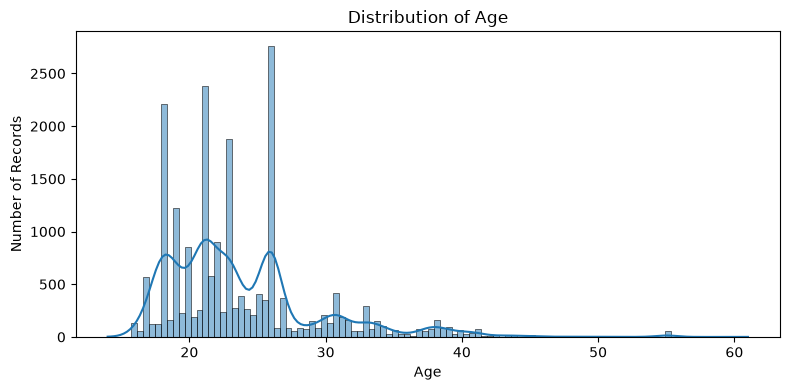

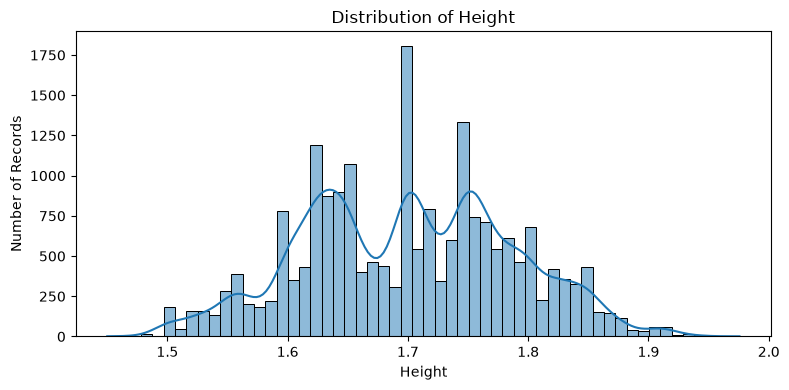

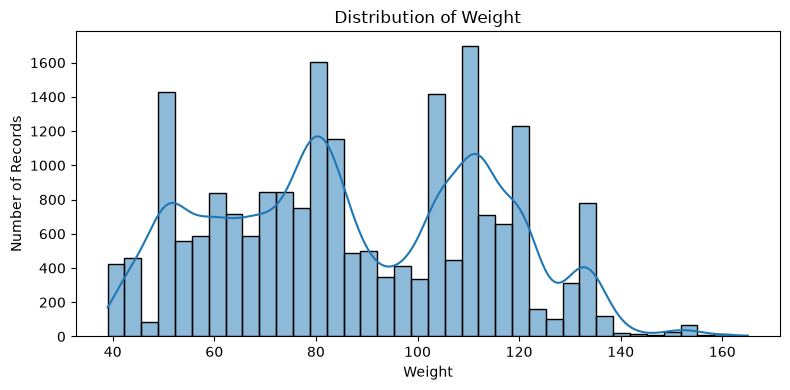

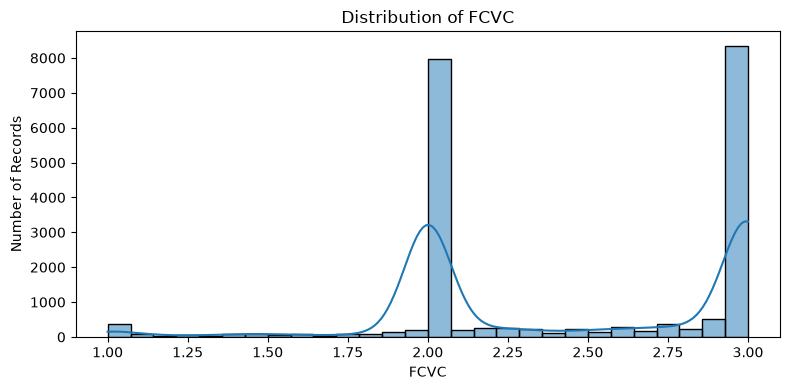

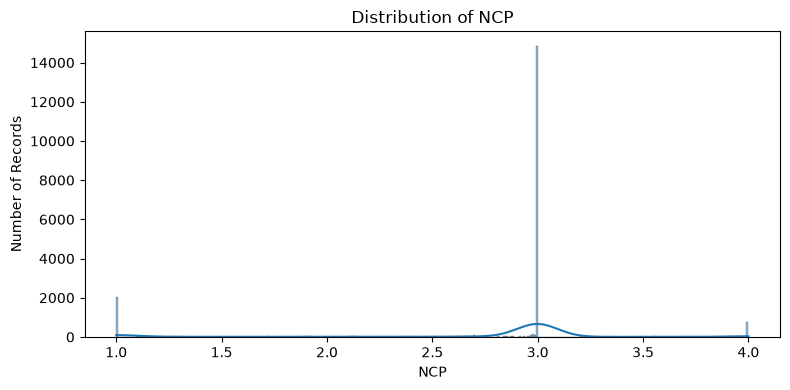

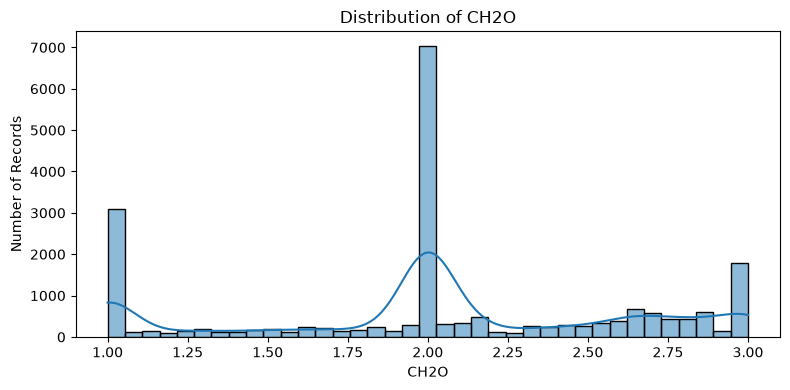

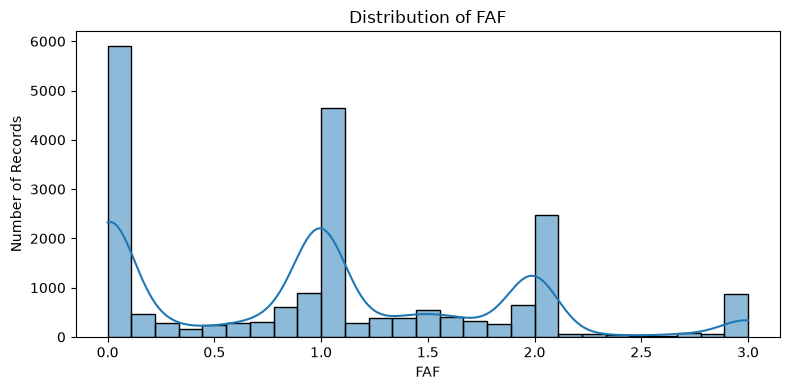

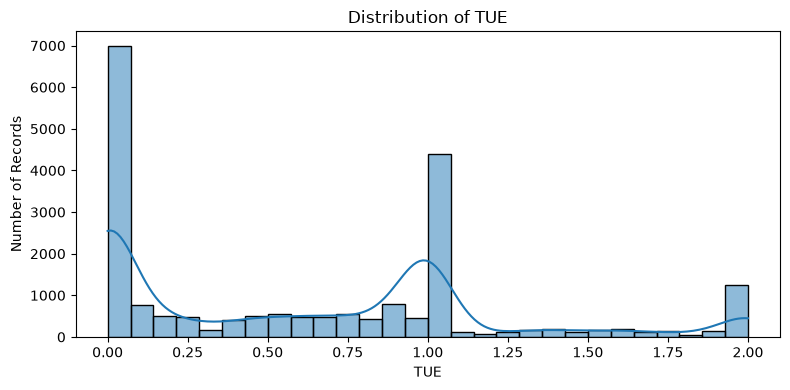

In [4]:
for column in numerical_features:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df,
        x=column,
        kde=True,
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Records")
    plt.tight_layout()
    plt.show()

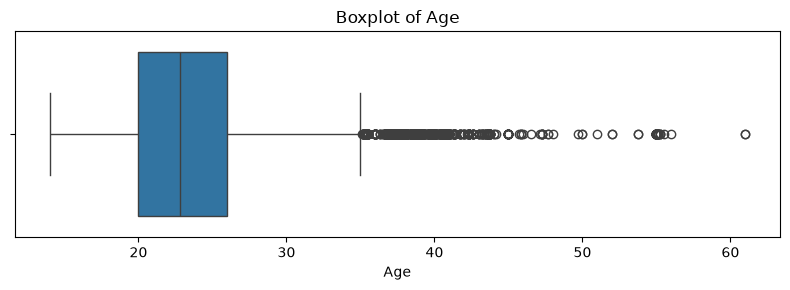

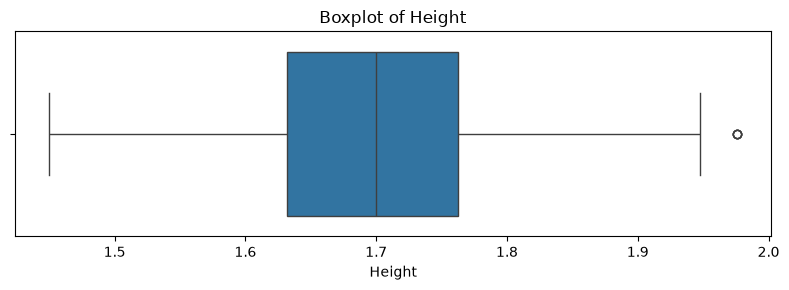

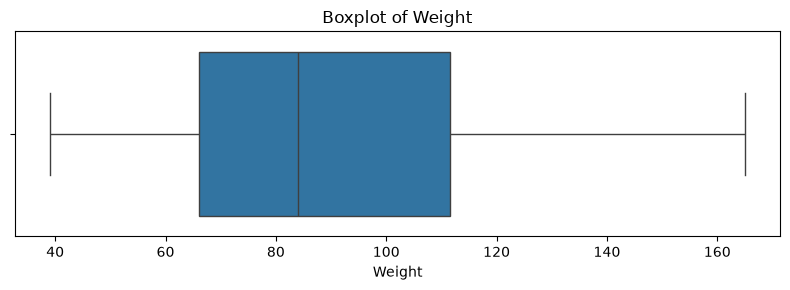

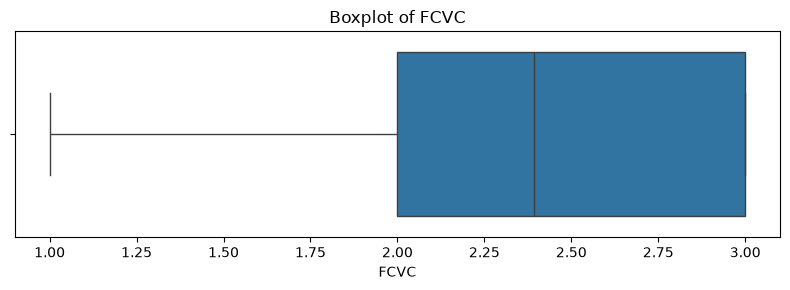

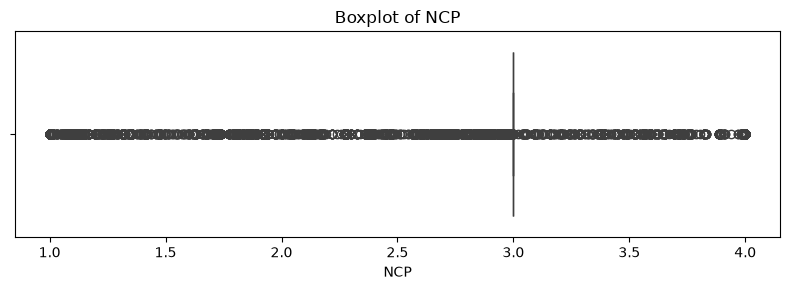

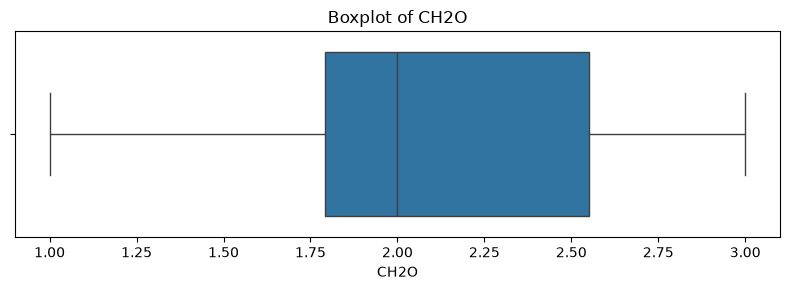

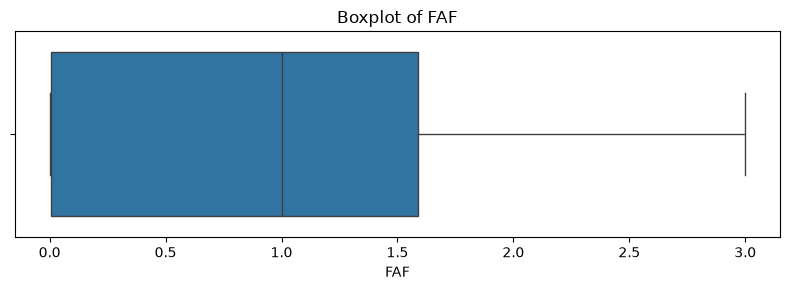

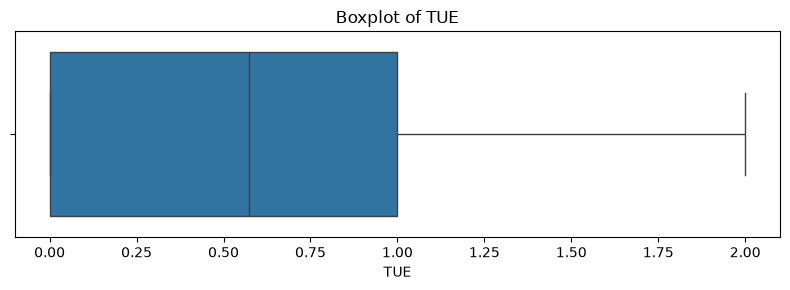

In [5]:
for column in numerical_features:
    plt.figure(figsize=(8, 3))

    sns.boxplot(
        data=df,
        x=column,
    )

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

In [6]:
for column in categorical_features:
    category_counts = df[column].value_counts()
    category_percentages = (
        df[column]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    category_summary = pd.DataFrame({
        "Count": category_counts,
        "Percentage": category_percentages,
    })

    print(f"\n{column}")
    print("-" * len(column))
    display(category_summary)


Gender
------


,Count,Percentage
Gender,,
Female,10422,50.21
Male,10336,49.79



family_history_with_overweight
------------------------------


,Count,Percentage
family_history_with_overweight,,
yes,17014,81.96
no,3744,18.04



FAVC
----


...

,Count,Percentage
SCC,,
no,20071,96.69
yes,687,3.31



CALC
----


,Count,Percentage
CALC,,
Sometimes,15066,72.58
no,5163,24.87
Frequently,529,2.55



MTRANS
------


,Count,Percentage
MTRANS,,
Public_Transportation,16687,80.39
Automobile,3534,17.02
Walking,467,2.25
Motorbike,38,0.18
Bike,32,0.15


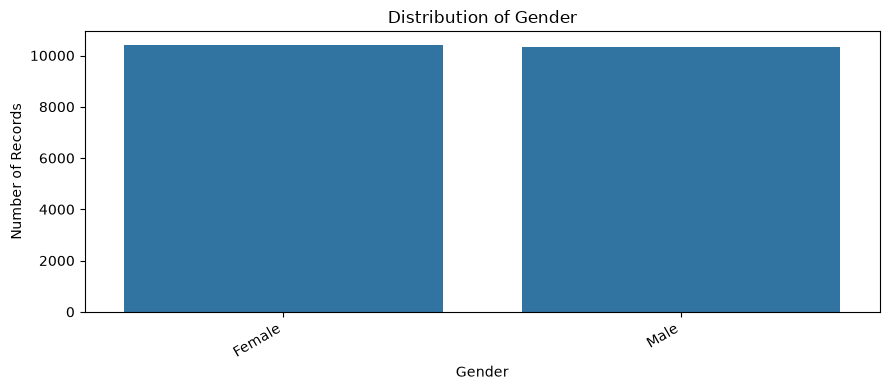

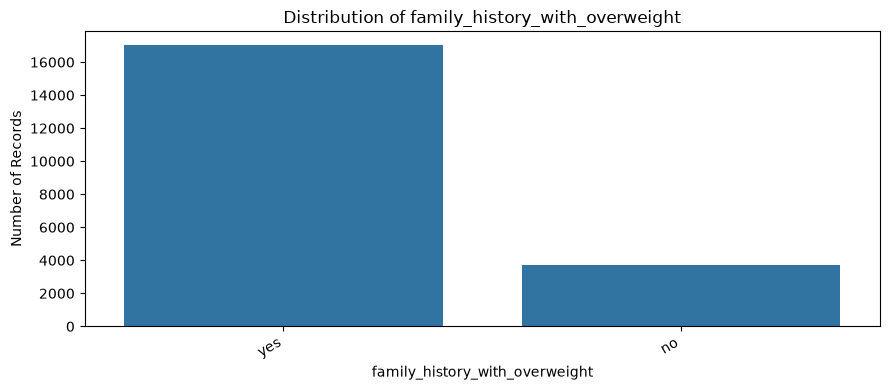

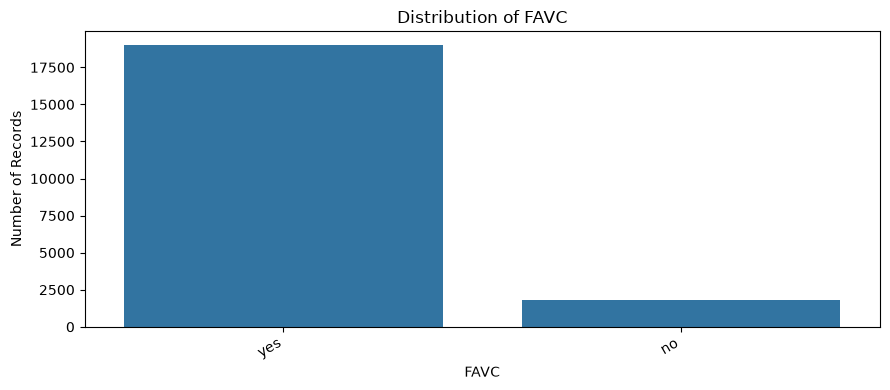

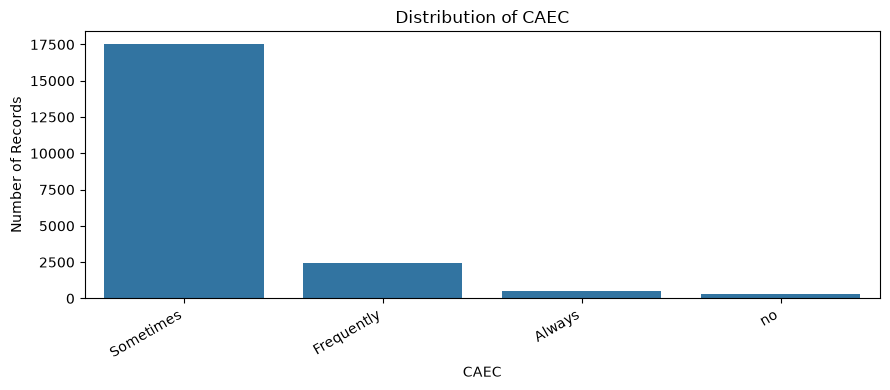

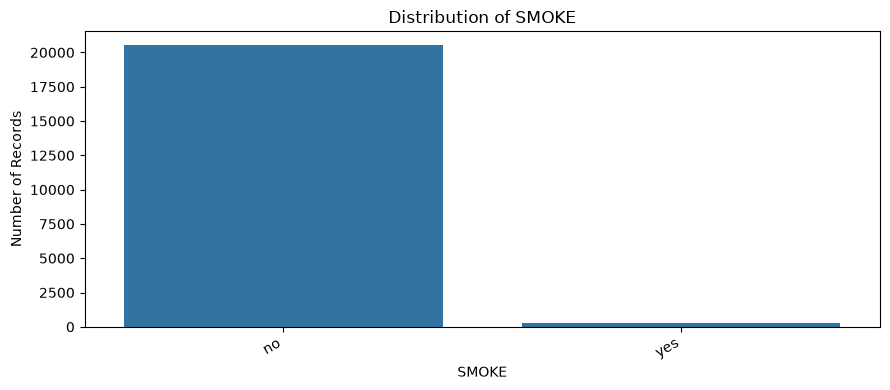

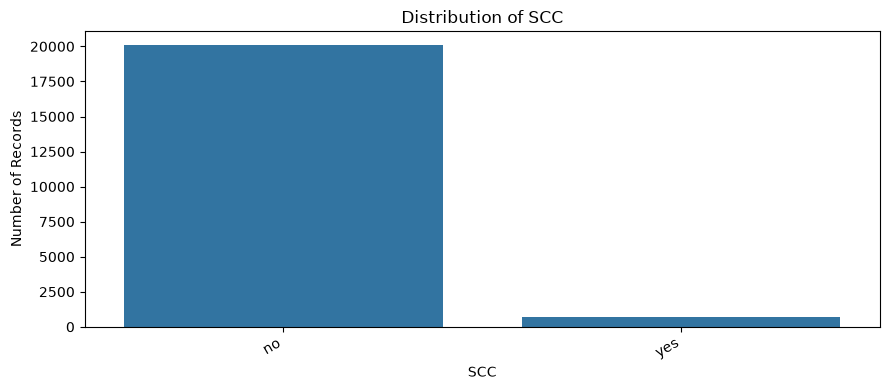

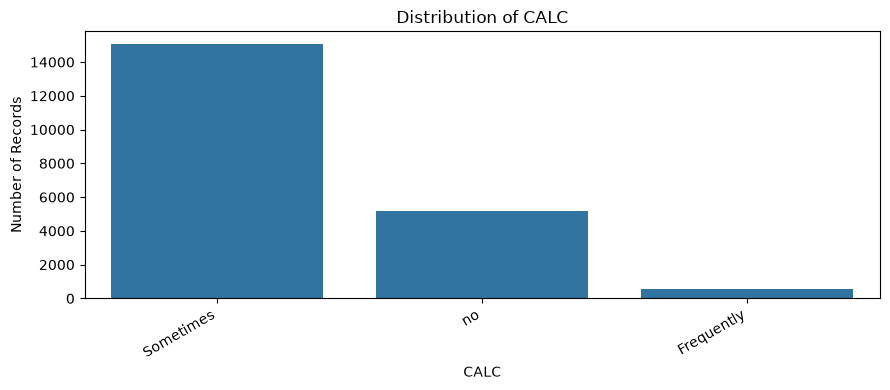

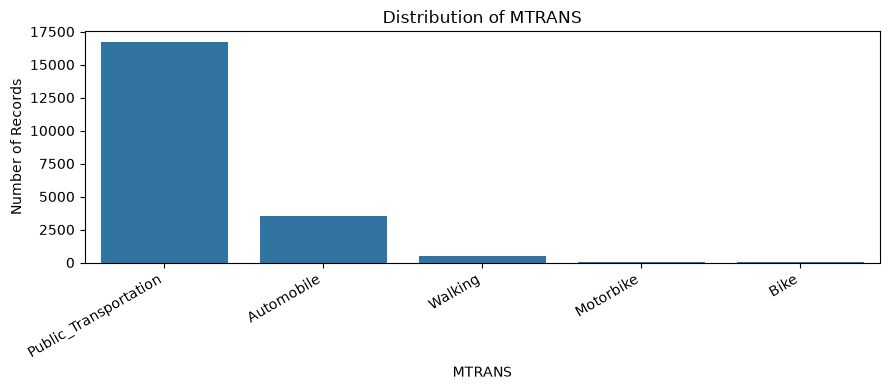

In [7]:
for column in categorical_features:
    category_order = df[column].value_counts().index

    plt.figure(figsize=(9, 4))

    sns.countplot(
        data=df,
        x=column,
        order=category_order,
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Records")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

In [8]:
category_extremes = []

for column in categorical_features:
    counts = df[column].value_counts()

    category_extremes.append({
        "Feature": column,
        "Most common category": counts.idxmax(),
        "Most common count": counts.max(),
        "Least common category": counts.idxmin(),
        "Least common count": counts.min(),
    })

category_extremes_df = pd.DataFrame(category_extremes)

category_extremes_df

,Feature,Most common category,Most common count,Least common category,Least common count
0,Gender,Female,10422,Male,10336
1,family_history_with_overweight,yes,17014,no,3744
2,FAVC,yes,18982,no,1776
3,CAEC,Sometimes,17529,no,279
4,SMOKE,no,20513,yes,245
5,SCC,no,20071,yes,687
6,CALC,Sometimes,15066,Frequently,529
7,MTRANS,Public_Transportation,16687,Bike,32


In [9]:
category_concentration = []

for column in categorical_features:
    most_common_percentage = (
        df[column]
        .value_counts(normalize=True)
        .max()
        * 100
    )

    category_concentration.append({
        "Feature": column,
        "Largest category percentage": round(
            most_common_percentage,
            2,
        ),
    })

category_concentration_df = pd.DataFrame(
    category_concentration
).sort_values(
    by="Largest category percentage",
    ascending=False,
)

category_concentration_df

,Feature,Largest category percentage
4,SMOKE,98.82
5,SCC,96.69
2,FAVC,91.44
3,CAEC,84.44
1,family_history_with_overweight,81.96
7,MTRANS,80.39
6,CALC,72.58
0,Gender,50.21
